
## Objetivos

* Desarrollar las etapas definidas al inicio del proyecto para llevar un control y registro del avance a través del trabajo colaborativo.
* Identificar los problemas presentados hasta el momento en cada etapa para proponer soluciones que aseguren el desarrollo continuo del proyecto mediante herramientas de búsqueda, pruebas y ejemplos.
* Evaluar el comportamiento de cada etapa a través de las hipótesis planteadas y resultados esperados para organizar los avances futuros.

## Desarrollo

### Estadísticas del repositorio

Para llevar a cabo el desarrollo se utilizó un repositorio en el que todos forman parte como colaboradores. El control de versiones se hizo a cabo usando GitHub Desktop o comandos de git a través de CLI, según la facilidad de cada miembro.
El control de versiones se llevó a cabo sobre la misma rama para facilitar la integración del contenido y evitar los merge-conflicts. Aunque esto puede resultar en conflictos de la misma índole, se organizaron las participaciones para que cada miembro pueda trabajar sin problema.
Enlace al repositorio: [Grupo-4-Finanzas](https://github.com/JhosuaS/Grupo-4-Finanzas)

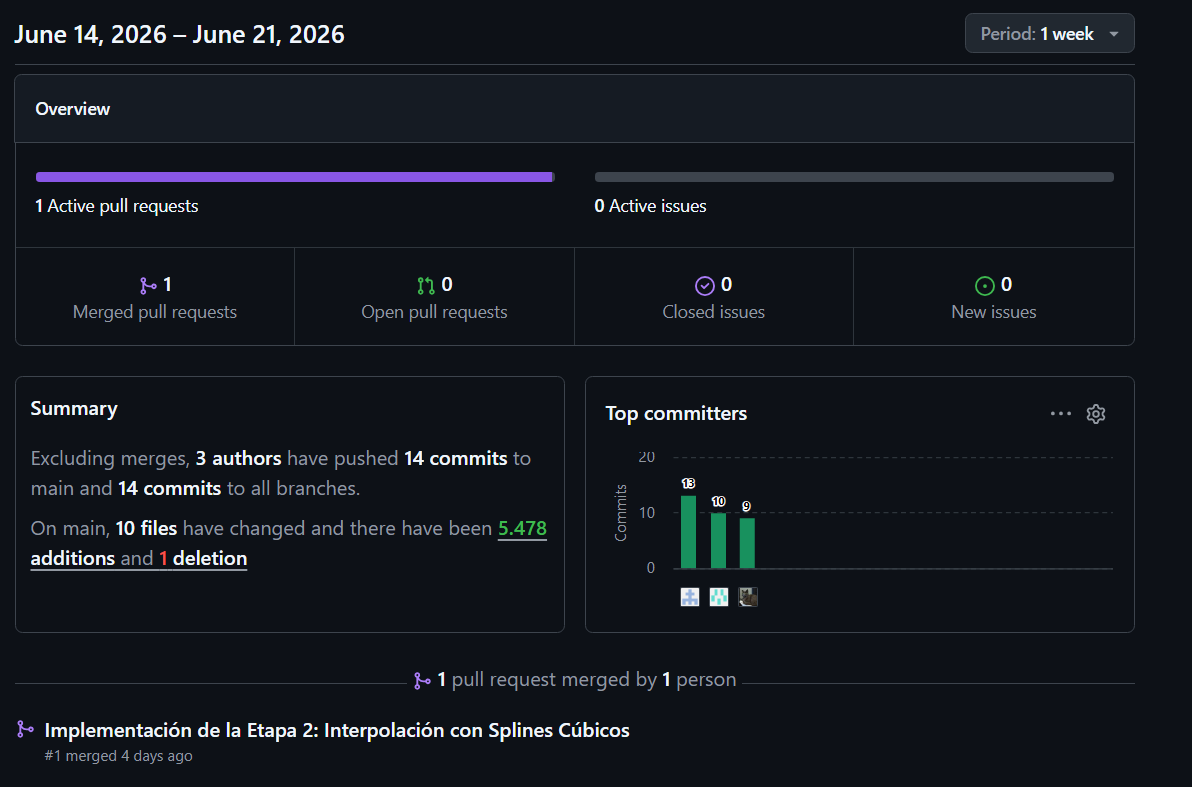

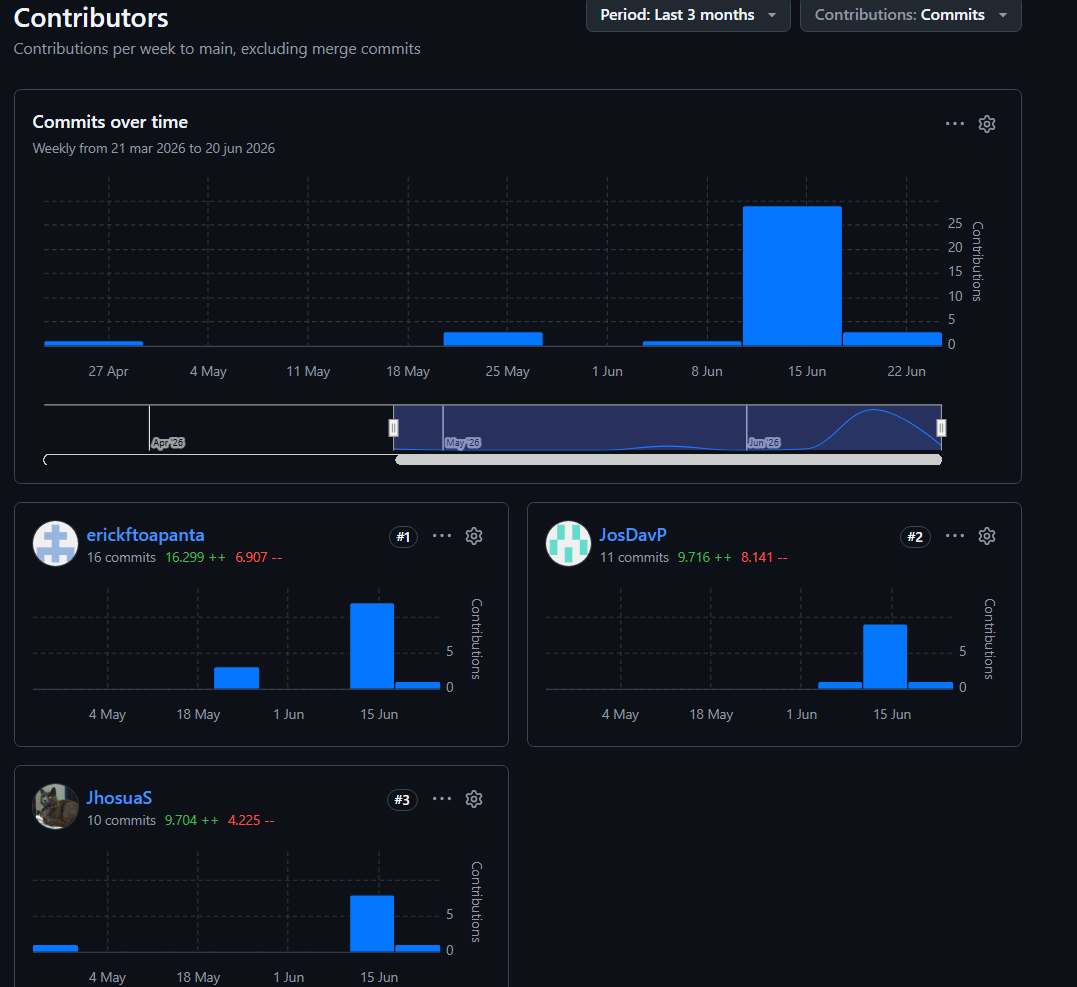

La captura muestra el avance del proyecto contribuido por cada miembro. Se nota especialmente el trabajo dedicado durante la semana del 14 al 21 de junio. Se muestran los nombres de usuario y los miembros según corresponde:
* `erickftoapanta`: Erick Toapanta
* `JosDavP`: José Pallares
* `JhosuaS`: Jhosua Saa

### Avance del proyecto

Para la ejecución de este proyecto se seleccionó el lenguaje de programación Python debido a su versatilidad y a sus potentes librerías para el manejo y procesamiento de datos numéricos. Antes de aplicar los algoritmos de interpolación o estimación de tendencias, fue indispensable llevar a cabo una fase exhaustiva de preprocesamiento en la Etapa 1. La presencia de ruidos temporales o formatos inadecuados puede distorsionar por completo la validez y la estabilidad de cualquier modelo matemático que se construya después.

Bajo este principio, las tareas iniciales del avance se concentraron en la purificación y la transformación de las variables del archivo `NASDAQ100.csv`. Al realizar la carga inicial del conjunto de datos, se identificó que las fechas calendario venían en un formato cualitativo que resulta imposible de operar algebraicamente en funciones continuas. Para solucionar esto y linealizar el eje del tiempo, se creó la variable independiente t, la cual asigna un valor numérico secuencial a cada registro. Este enfoque garantiza que cada incremento unitario equivalga exactamente a un día hábil de operación bursátil, eliminando los espacios vacíos de los fines de semana y feriados que habrían deformado el análisis.

De igual manera, para mitigar el riesgo de que la computadora acumule pequeños errores de redondeo al resolver las matrices y sistemas de ecuaciones en las fases posteriores, se aplicó una estandarización estricta por redondeo a 8 cifras decimales en el precio de cierre (Close). Con esta preparación de la Etapa 1, se logró aislar con total precisión la ventana temporal de interés de 5 años (octubre 2019 - octubre 2024), dejando el set de datos optimizado y listo para la construcción del spline cúbico en la Etapa 2

**Etapa 1: Tratamiento de datos**
i) *Importación de librerías y lectura del archivo:* Se arranca el script cargando los módulos necesarios para la manipulación matricial (pandas y numpy), gráficos (matplotlib) e interpolación avanzada (scipy). A continuación, se realiza la lectura del archivo de datos y se convierte la columna de fechas de texto plano a formato cronológico (datetime).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from pathlib import Path

In [ ]:
# --- 1. TRATAMIENTO DE DATOS ---
dataset_path = Path.cwd() / 'DATASET' / 'NASDAQ100.csv'
if not dataset_path.exists():
    dataset_path = Path.cwd().parent / 'DATASET' / 'NASDAQ100.csv'

try:
    df_total = pd.read_csv(dataset_path)

    # Convertir la columna Date a formato fecha
    df_total['Date'] = pd.to_datetime(df_total['Date'])

ii) *Filtrado de la ventana de 5 años y redondeo de precisión:* Se establece el rango exacto post-pandemia de interés. Con una máscara lógica, se extrae el segmento de datos requerido eliminando registros fuera de los límites. Posterior a esto, se aplica un redondeo estricto a 8 decimales en el precio de cierre para controlar la precisión en la aritmética de punto flotante de la computadora.

In [ ]:
# FILTRADO (Oct 2019 - Oct 2024)
    fecha_inicio = pd.to_datetime('2019-10-01')
    fecha_fin = pd.to_datetime('2024-10-31')
    mascara = (df_total['Date'] >= fecha_inicio) & (df_total['Date'] <= fecha_fin)

    # Nos quedamos solo con los datos que cumplen la condición
    df_analisis = df_total.loc[mascara].sort_values('Date').reset_index(drop=True).copy()

    # Estandarización a 8 decimales por redondeo
    df_analisis['Close'] = df_analisis['Close'].round(8)

iii) *Creación de la variable lineal temporal (t):* Para evitar operar con objetos calendario sobre las funciones continuas, se genera una secuencia ordenada de números enteros utilizando el tamaño total de la muestra limpia. Cada entero describe una jornada bursátil activa.

In [ ]:
 # Creación de variable independiente t (días de operación)
    df_analisis['t'] = np.arange(len(df_analisis))

    print("--- ETAPA 1: TRATAMIENTO COMPLETADO ---")
    print(f"Rango de datos: {df_analisis['Date'].min().date()}" 
          f"a {df_analisis['Date'].max().date()}")
    print(f"Total de registros (n): {len(df_analisis)}")
    print(f"Precio Mínimo: {df_analisis['Close'].min():.2f}" 
          f"| Precio Máximo: {df_analisis['Close'].max():.2f}")

except Exception as e:
    print(f"Error al procesar los datos: {e}")

**Etapa 2: Interpolación y Suavizado**

En esta fase se utiliza el set de datos purificado para construir la trayectoria continua del índice, buscando mitigar las fluctuaciones rápidas del mercado sin perder la memoria histórica de los datos reales. 
i) *Preparación matricial de vectores:* Se extraen los datos limpios de las columnas de nuestro DataFrame y se convierten en arreglos unidimensionales nativos (arrays de NumPy). De esta forma, las variables independientes (t) y dependientes (y) quedan listas en memoria para ser procesadas de forma eficiente por los algoritmos matemáticos.

In [ ]:
# 1. Preparación de vectores para la interpolación
t = df_analisis['t'].values
y = df_analisis['Close'].values

ii) *Ajuste y cálculo del Spline Cúbico Natural:* Se ejecuta el núcleo del algoritmo de interpolación por tramos utilizando la función CubicSpline. Al definir el parámetro bc_type='natural', el programa obliga matemáticamente a que la segunda derivada en las fronteras inicial y final de todo el intervalo sea igual a cero. Esto ayuda a absorber las tensiones de la curva y previene el Fenómeno de Runge, evitando que se generen oscilaciones falsas o exageradas en los extremos del gráfico.

In [ ]:
# 2. Cálculo de los coeficientes del spline cúbico natural
# Garantiza que la segunda derivada en los extremos sea cero
spline = CubicSpline(t, y, bc_type='natural')

iii) *Generación del espacio denso de evaluación:* Para evaluar el comportamiento de la función continua construida, se utiliza np.linspace para crear una malla fina de 1000 puntos intermedios distribuidos uniformemente entre el día inicial y el final. Al pasar este vector denso (t_suave) por nuestro spline, se obtienen los puntos de precio suavizados (y_spline) que darán forma a la curva continua.

In [ ]:
# 3. Generación de un espacio muestral denso para visualización fluida
t_suave = np.linspace(t.min(), t.max(), 1000)
y_spline = spline(t_suave)

iv) *Configuración visual y generación del gráfico comparativo:* Finalmente, se construye el entorno gráfico utilizando Matplotlib. Para lograr un contraste analítico claro, los datos reales de la bolsa se grafican en color azul con una opacidad reducida `(alpha=0.5)`, representando el "ruido" diario del mercado. Encima de ellos se superpone la curva del spline cúbico en color verde y con mayor grosor, permitiendo observar visualmente cómo el modelo matemático suaviza la dinámica de precios sin distorsionar la trayectoria real.

In [ ]:
# 4. Configuración del entorno gráfico estandarizado
plt.figure(figsize=(10, 6))

# Trazado de datos crudos con opacidad reducida para no saturar
plt.plot(t, y, color='blue', alpha=0.5, label='Precio Real (Ruido)')

# Trazado de la curva interpolada
plt.plot(t_suave, y_spline, color='green', linewidth=2, label='Suavizado (Spline Cúbico)')

plt.title('Suavizado de la Dinámica de Precios del NASDAQ-100')
plt.xlabel('Días Normalizados')
plt.ylabel('Precio de Cierre (Puntos)')
plt.legend()
plt.grid(True)
plt.show()

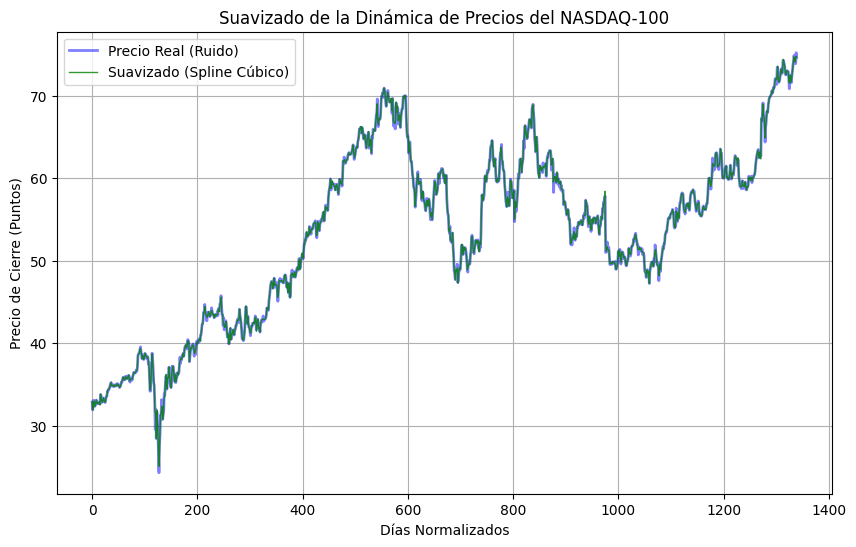

Una vez se ha conseguido interpolar, se tiene una aproximación clara sobre la curva de Mínimos Cuadrados que describa la tendencia. A partir de la imagen se pueden observar 2 picos y 2 valles de mayor relevancia, sin considerar el despunte final que realiza la curva por sobre los 70 puntos.

**Etapa 3: Tendencia por mínimos cuadrados**

La estructura en esta etapa consiste en la búsqueda de una tendencia que cubra los macro eventos durante el período de análisis, la hipótesis inicial define que un polinomio de grado 4 o superior consiga el ajuste adecuado, a partir de los picos y valles que se generen por cada evento definido.
El método de mínimos cuadrados genera un polinomio de grado n tal que:
$P(t) = a_0 + a_1t + a_2t^2 + ... + a_nt^n$.
En este punto es importante indicar que el sistema resultante de mínimos cuadrados está sobredeterminado, por lo que se usará un sistema de ecuaciones normales para minimizar el error cuadrático. Es decir, se generaría una ecuación de regresión por cada día, por lo que para el tamaño del dataset obtendríamos un sistema $1300 * m$ con $ m = n + 1$ mucho menor que 1300 días que es el aproximado de días de evaluación. Por lo que se generaría una matriz rectangular conocida como matriz de Vandermonde [@vandermonde] cuyos coeficientes al ser leídos por fila siguen la misma construcción de un polinomio como el que genera mínimos cuadrados, dado a esta conveniencia vandermonde y mínimos cuadrados suelen ser usados en conjunto para determinar modelos de tendencia y regresión [@vandermonde_maiz]. Para resolver este inconveniente se realiza la operación:
$$(A^T A) x = A^T y$$
Con la que se consigue un sistema $Cx = d$ donde, $C = A^T A$ y $d = A^T b$ que es un sistema cuadrado de orden $m * m$ y se garantiza su solución. Así pues se determina un polinomio mediante mínimos cuadrados que se ajuste a la tendencia.

Al tener el código estructurado por celdas, se puede acceder con las variables de la etapa anterior al método de mínimos cuadrados. Esta etapa emplea métodos de numpy para resolver el sistema matricial planteado. Primero, se definen las variables y el grado de predicción de la tendencia para luego construir la matriz de Vandermonde.

In [ ]:
# ETAPA 3: REGRESIÓN POLINOMIAL (MÍNIMOS CUADRADOS)
#1. Definir variables y grado de tendencia
t = df_analisis['t'].values 
y = df_analisis['Close'].values
grado = 4
num_coeficientes = grado + 1

#2. Construcción de la matriz
A = np.zeros((len(t), num_coeficientes))
for i in range (0, num_coeficientes):
    for j in range(len(t)): 
        A[j][i] = t[j] ** i

A_T = np.transpose(A)

`numpy` presenta una serie de métodos que pueden ser aprovechados para resolver el sistema matricial, se optó por usar estos métodos en lugar de los bucles que recorran la matriz por el costo computacional que implicaría realizar un producto matricial con las dimensiones especificadas antes (aprox. 1300 * 5). A continuación, se resuelve el sistema equivalente $Ax=b$ de manera tradicional y luego se grafican los resultados de la tendencia frente a los resultados obtenidos por la etapa 2 para comparar el ruido suavizado frente a la tendencia.

In [ ]:
#4. Resolver el sistema cuadrado
coeficientes = np.linalg.solve(matriz_normal, vector_normal)
y_pred = np.dot(A, coeficientes)

#5. Gráfica
plt.figure(figsize=(10, 6)) 
plt.plot(t, y, color='blue', alpha=0.5, label='Precio Real (Ruido)')
plt.plot(t, y_pred, color='red', linewidth=2, label='Tendencia (Mínimos Cuadrados)')
plt.title('Ajuste de Tendencia del NASDAQ-100 mediante Mínimos Cuadrados')
plt.xlabel('Días Normalizados')
plt.ylabel('Precio de Cierre (Puntos)')
plt.legend()
plt.grid(True)
plt.show()

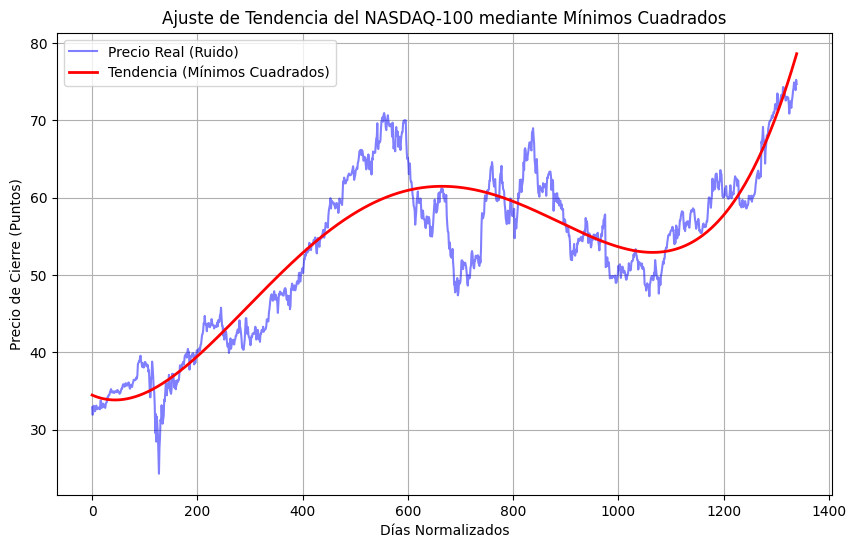

En la figura se observa que la tendencia describe de manera adecuada la curva con ruido, sin embargo, no se cuenta actualmente con un indicador que describe el porcentaje o grado en el que la tendencia descrita se aleja de los valores reales. No obstante, la curva actual puede ser utilizada por el método de Newton - Raphson para los cálculos de predicción correspondientes. De igual modo, con solo observar la tendencia se espera que las predicciones sean irreales al pasar los 1400 días, por lo que la predicción planteada de 85 puntos sigue siendo viable.

**Etapa 4: Punto Objetivo con Newton - Raphson**

En esta etapa final se busca determinar el instante $t$ (día hábil de operación) en el cual el índice NASDAQ-100 alcanzaría un valor objetivo de **85 puntos**, utilizando como modelo matemático el polinomio de tendencia $P(t)$ obtenido en la Etapa 3 mediante mínimos cuadrados.

i) *Planteamiento del problema:*
Se define la función raíz $g(t) = P(t) - 85$, de modo que el valor de $t$ que satisface $g(t) = 0$ corresponde al día en que la tendencia ajustada alcanza el objetivo. El método de Newton-Raphson aproxima dicha raíz mediante la fórmula iterativa:

$$t_{n+1} = t_n - \frac{g(t_n)}{g'(t_n)} = t_n - \frac{P(t_n) - 85}{P'(t_n)}$$

donde $P'(t)$ es la derivada analítica del polinomio de grado 4 obtenido previamente.

ii) *Justificación de la suavidad de la curva:* La convergencia de Newton-Raphson exige que la función evaluada posea una derivada continua y bien definida en todo el intervalo de búsqueda. Trabajar directamente sobre el precio de cierre diario (la serie cruda) introduciría discontinuidades de pendiente día a día —el "ruido" identificado desde la Etapa 1— que generarían una derivada errática e impedirían la convergencia del método. Por esta razón, en las etapas previas se suavizó la trayectoria del índice (Spline Cúbico, Etapa 2) y posteriormente se ajustó una tendencia macro mediante mínimos cuadrados (Etapa 3): el polinomio resultante $P(t)$ es una función infinitamente diferenciable, con derivada $P'(t)$ continua en todo su dominio, lo cual garantiza la estabilidad numérica y la convergencia del método en el intervalo de análisis.

iii) *Selección de la semilla inicial $t_0$:* Dado que el precio máximo observado en el periodo de estudio es inferior al objetivo planteado de 85 puntos, la raíz buscada corresponde a una extrapolación futura de la tendencia. Se realiza un barrido del dominio extendido más allá del último día registrado para localizar el cambio de signo de $g(t)$ y obtener así una semilla $t_0$ que garantice la convergencia del método.

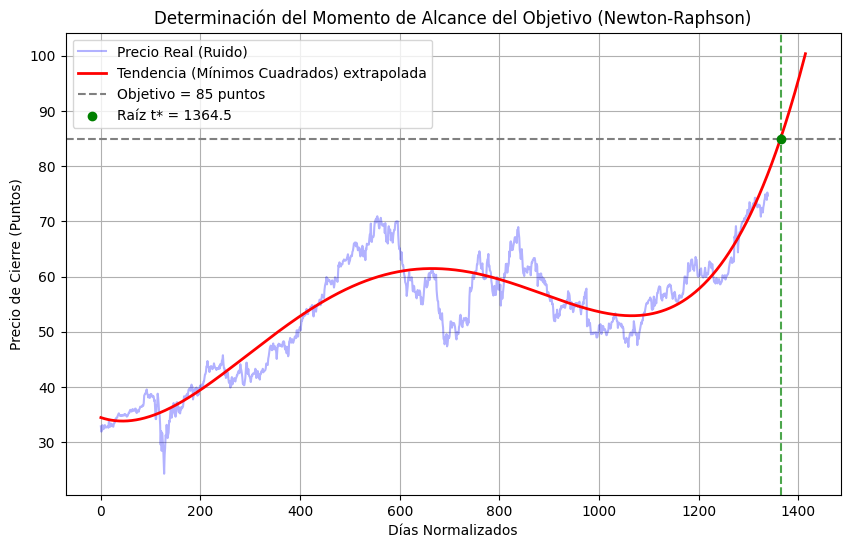

La gráfica de predicción muestra que los 85 puntos se alcanzaron al 24 de diciembre de 2024, es decir, 2 meses después del fin de la fecha del dataset. De igual modo se observa que la tendencia se dispara por sobre este límite por lo que cualquier predicción podría ser equívoca. Dado el comportamiento real de los mercados una tendencia al alza jamás es permanente por lo que la tendencia actual permite la descripción de los datos obtenidos y realiza predicciones muy limitadas.

### Estado actual de las fases propuestas

* **Fase 1:** La carga de datos, limpieza y normalización del dataset se encuentran implementadas. No se han presentado problemas hasta el momento.
* **Fase 2**: La implementación actual está trabajando con librerías externas que operan como funciones de caja negra, pese a que reduce el coste computacional debería revisarse la implementación mediante algoritmos vistos en clase y su integración con etapas posteriores.
* **Fase 3**: La hipótesis de un polinomio de grado 4 para describir la tendencia y los macroeventos en el período de anális parece ser acertada. Se está buscando índices o medidas adicionales que sirvan como punto objetivo de comparación para determinar que tan acertada es la tendencia respecto a los datos reales.
* **Fase 4:** el método para encontrar raíces funciona y se alcanza una fecha para la predicción objetivo. El dataset original presente el precio de cierre en puntos por lo que se está buscando una forma de conseguir los índices en miles de puntos y comparar la predicción con una fecha real en la que se haya alcanzado dicho puntaje, o el puntaje real obtenido a la fecha de predicción.

## Conclusiones

Durante el desarrollo de este avance se evaluó que el dataset presentaba ya valores normalizados para no operar con rangos en miles. De igual modo se consiguió estandarizar las fechas para que funcionen como una variable continua. En cuánto a los inconvenientes presentados se detectó la necesidad de buscar un método de conversión para volver la escala a miles y realizar comparaciones con los valores predichos, al igual que implementar medidas de comparación o incluir las columnas High y Low para mostrar barras de tendencia o rangos en el análisis.

## Recomendaciones

* Es óptimo para el próximo avance separar cada fase dentro del repositorio para que sean accedidas como módulos o métodos separados. 
* Revisar métodos o aplicaciones que permitan retomar la escala de miles usada en NASDAQ 100.
* Contrastar la tendencia con valores reales mediante indicadores adicionales o índices de regresión.

## Referencias
::: {#refs}
:::